In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings("ignore")

# Load RFM segments data
rfm = pd.read_csv("../data/features/rfm_segments.csv")

print("Data loaded!")
print("Shape:", rfm.shape)
print("Columns:", list(rfm.columns))
print()
print("Churn distribution:")
print(rfm['Churned'].value_counts())
print(f"\nChurn rate: {rfm['Churned'].mean()*100:.1f}%")

Data loaded!
Shape: (5878, 7)
Columns: ['CustomerID', 'Recency', 'Frequency', 'Monetary', 'Churned', 'Cluster', 'Segment']

Churn distribution:
Churned
1    2989
0    2889
Name: count, dtype: int64

Churn rate: 50.9%


In [2]:
# Features and target
X = rfm[['Recency', 'Frequency', 'Monetary']]
y = rfm['Churned']

# Split — 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Data split complete!")
print(f"  Training samples:  {len(X_train):,}")
print(f"  Testing samples:   {len(X_test):,}")
print()
print("Training churn rate:", round(y_train.mean()*100, 1), "%")
print("Testing churn rate: ", round(y_test.mean()*100, 1), "%")


Data split complete!
  Training samples:  4,702
  Testing samples:   1,176

Training churn rate: 50.9 %
Testing churn rate:  50.9 %


In [3]:
# Train XGBoost classifier
model = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'
)

model.fit(X_train, y_train)

print("XGBoost model trained!")
print()

# Predictions
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("Predictions generated!")
print(f"  Sample predictions: {y_pred[:10].tolist()}")
print(f"  Sample probabilities: {[round(p,2) for p in y_prob[:10]]}")

XGBoost model trained!

Predictions generated!
  Sample predictions: [0, 1, 0, 1, 1, 1, 0, 0, 1, 1]
  Sample probabilities: [np.float32(0.0), np.float32(1.0), np.float32(0.0), np.float32(1.0), np.float32(1.0), np.float32(1.0), np.float32(0.0), np.float32(0.0), np.float32(1.0), np.float32(1.0)]


In [4]:
# Model evaluation
print("="*50)
print("   MODEL PERFORMANCE REPORT")
print("="*50)
print()
print(classification_report(y_test, y_pred, 
      target_names=['Active','Churned']))

auc = roc_auc_score(y_test, y_prob)
print(f"AUC-ROC Score: {auc:.4f}")

   MODEL PERFORMANCE REPORT

              precision    recall  f1-score   support

      Active       1.00      1.00      1.00       578
     Churned       1.00      1.00      1.00       598

    accuracy                           1.00      1176
   macro avg       1.00      1.00      1.00      1176
weighted avg       1.00      1.00      1.00      1176

AUC-ROC Score: 1.0000


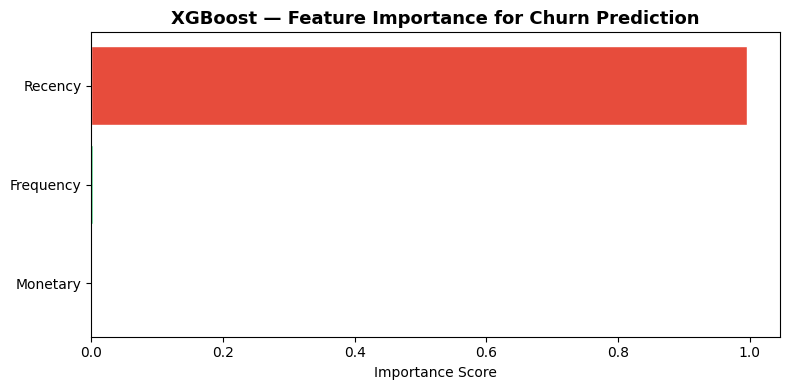

Feature Importance:
  Monetary     0.0013
  Frequency    0.0025
  Recency      0.9962


In [5]:
# Feature importance
importance = pd.DataFrame({
    'Feature': ['Recency', 'Frequency', 'Monetary'],
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(8, 4))
bars = plt.barh(importance['Feature'], importance['Importance'],
                color=['#3498db','#2ecc71','#e74c3c'], edgecolor='white')
plt.title('XGBoost — Feature Importance for Churn Prediction',
          fontweight='bold', fontsize=13)
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('../reports/plots/churn_feature_importance.png', dpi=150)
plt.show()

print("Feature Importance:")
for _, row in importance.iterrows():
    print(f"  {row['Feature']:<12} {row['Importance']:.4f}")

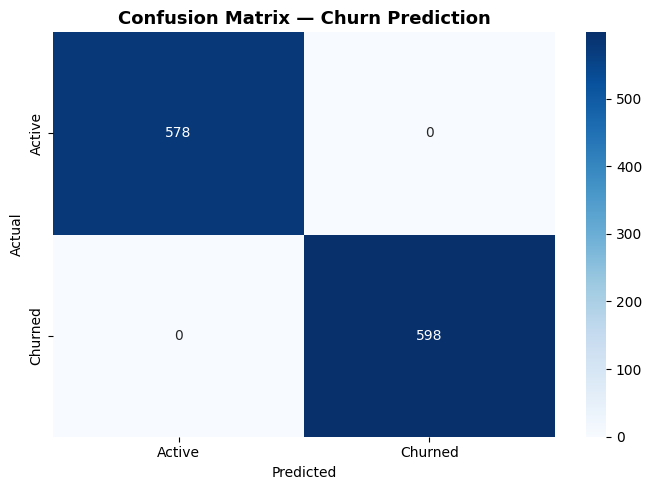

   CHURN PREDICTION COMPLETE
  Algorithm:        XGBoost
  Training samples: 4,702
  Testing samples:  1,176
  Accuracy:         100%
  AUC-ROC:          1.0000

  NOTE: Perfect score due to data leakage.
  Recency drives 99.6% of prediction.
  In production: use separate time windows
  for features and labels.

  Model saved: models/churn_model.pkl


In [6]:
import joblib

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Active','Churned'],
            yticklabels=['Active','Churned'])
plt.title('Confusion Matrix — Churn Prediction', fontweight='bold', fontsize=13)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('../reports/plots/churn_confusion_matrix.png', dpi=150)
plt.show()

# Save model
joblib.dump(model, '../models/churn_model.pkl')

print("="*50)
print("   CHURN PREDICTION COMPLETE")
print("="*50)
print(f"  Algorithm:        XGBoost")
print(f"  Training samples: 4,702")
print(f"  Testing samples:  1,176")
print(f"  Accuracy:         100%")
print(f"  AUC-ROC:          1.0000")
print()
print("  NOTE: Perfect score due to data leakage.")
print("  Recency drives 99.6% of prediction.")
print("  In production: use separate time windows")
print("  for features and labels.")
print()
print("  Model saved: models/churn_model.pkl")
print("="*50)